# 🛒 eBay Customer RFM Analysis & Marketing Strategy

**Dataset:** Online Retail II (UCI Machine Learning Repository)  
**Period:** Dec 2009 – Dec 2011  
**Business Goal:** Segment customers by purchasing behavior to prioritise marketing spend and drive revenue growth.

---

## 📋 Key Questions This Notebook Answers
1. **Who are the high-value customers?** → Champions, Loyal, Potential Loyalists
2. **Which segments need urgent attention?** → At-Risk, Hibernating, Can't Lose Them
3. **Where should marketing budget go?** → Tier-level revenue vs customer share analysis
4. **What actions should each segment receive?** → Personalised marketing strategy map

---

## 🗺️ Notebook Structure
| # | Section | Output |
|---|---------|--------|
| 1 | Data Overview & Preparation | Clean dataset, summary stats |
| 2 | RFM Metric Calculation | One row per customer |
| 3 | RFM Scoring (1–5) | Quintile scores + combined RFM string |
| 4 | Customer Segmentation | 11-segment map |
| 5 | Segment Size & Revenue | Treemap + revenue share |
| 6–8 | Weekly Behavior by Tier | Bar charts (High / Mid / Low) |
| 9 | Full Segment Snapshot | Executive dashboard table |
| 10 | Scatter Plot | Recency vs Spend bubble chart |
| 11 | CV-RFM Analysis | Customer value within segments |
| 12 | Tier Opportunity Analysis | Revenue vs Customer % comparison |
| 13 | Key Insights | Business takeaways (stakeholder-ready) |
| 14 | Marketing Strategy Map | Segment → action recommendations |
| 15 | Implementation Roadmap | 3-month action plan + KPIs |
| 16 | Export | CSV outputs for downstream use |


## ⚙️ 0. Environment Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import datetime as dt
import squarify
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

# ── Shared colour palette (set once, reused throughout) ──────────────────
SEGMENT_ORDER = [
    'Champion', 'Loyal Customer', 'Potential Loyalist',
    'Need Attention', 'Promising', 'New Customer', 'About to Sleep',
    'At Risk', "Can't Lose Them", 'Hibernating', 'Lost', 'Other'
]
palette    = sns.color_palette('Set3', len(SEGMENT_ORDER))
color_map  = dict(zip(SEGMENT_ORDER, palette))

TIER_COLORS = {'High Value': '#5cb85c', 'Mid Value': '#f0ad4e', 'Low Value': '#d9534f'}

print("✅ Environment ready.")

✅ Environment ready.


## 📥 1. Data Overview & Preparation

**Purpose:** Load both year-sheets, deduplicate, remove nulls, and engineer the `Total Price` column.  
We also filter out returns (negative `Quantity`) and stock adjustments (non-numeric `Invoice`).


In [3]:
# ── Load ──────────────────────────────────────────────────────────────────
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010', parse_dates=['InvoiceDate'])
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011', parse_dates=['InvoiceDate'])
df  = pd.concat([df1, df2], ignore_index=True)

print(f"Raw rows        : {df.shape[0]:,}")
print(f"Raw columns     : {df.shape[1]}")
print(f"Date range      : {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")


Raw rows        : 1,067,371
Raw columns     : 8
Date range      : 2009-12-01 → 2011-12-09
Unique customers: 5,942


In [4]:
# ── Clean ─────────────────────────────────────────────────────────────────
df.drop_duplicates(inplace=True)
df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price'], inplace=True)

# Remove returns (negative quantity) and adjustment entries
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# Engineer revenue column
df['Total Price'] = df['Quantity'] * df['Price']

print(f"Cleaned rows    : {df.shape[0]:,}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")
print(f"Unique invoices : {df['Invoice'].nunique():,}")
print(f"Total revenue   : ${df['Total Price'].sum():,.0f}")
print()
print("── Sample rows ──")
df.head(3)

Cleaned rows    : 779,425
Unique customers: 5,878
Unique invoices : 36,969
Total revenue   : $17,374,804

── Sample rows ──


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total Price
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0


In [5]:
# ── Missing value check ───────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("✅ No missing values after cleaning.")
else:
    print("⚠️ Missing values remaining:")
    print(missing)

print()
print("── Data types ──")
print(df.dtypes)

✅ No missing values after cleaning.

── Data types ──
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
Total Price           float64
dtype: object


## 📐 2. RFM Metric Calculation

| Metric | Definition | Direction |
|--------|-----------|-----------|
| **Recency** | Days since last purchase | Lower = better |
| **Frequency** | Total number of invoices | Higher = better |
| **Monetary** | Total spend (£) | Higher = better |

*Observation date is set to 1 day after the last transaction to avoid zero-recency bias.*


In [6]:
# ── Observation date ─────────────────────────────────────────────────────
obs_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Observation date: {obs_date.date()}")

# ── Per-customer aggregation ──────────────────────────────────────────────
df_rfm = (
    df.groupby('Customer ID')
    .agg(
        Recency   = ('InvoiceDate',  lambda x: (obs_date - x.max()).days),
        Frequency = ('Invoice',      'nunique'),   # unique invoices, not rows
        Monetary  = ('Total Price',  'sum')
    )
    .reset_index()
)

print(f"\nRFM table shape : {df_rfm.shape}")
print()
print("── Summary statistics ──")
df_rfm[['Recency','Frequency','Monetary']].describe().round(1)

Observation date: 2011-12-10

RFM table shape : (5878, 4)

── Summary statistics ──


,Recency,Frequency,Monetary
count,5878.0,5878.0,5878.0
mean,201.3,6.3,2955.9
std,209.3,13.0,14440.9
min,1.0,1.0,3.0
25%,26.0,1.0,342.3
50%,96.0,3.0,867.7
75%,380.0,7.0,2248.3
max,739.0,398.0,580987.0


## 🎯 3. RFM Scoring (1–5 Scale)

Quintile-based scoring converts raw metrics into comparable 1–5 scores.  
- **Recency:** score 5 = most recent buyers  
- **Frequency & Monetary:** score 5 = highest buyers / spenders  

The three scores are concatenated into a 3-digit **RFM string** (e.g., `555` = perfect Champion).


In [7]:
# ── Quintile scoring ─────────────────────────────────────────────────────
df_rfm['R Score'] = pd.qcut(df_rfm['Recency'],   5, labels=[5,4,3,2,1])  # inverted
df_rfm['F Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['M Score'] = pd.qcut(df_rfm['Monetary'],  5, labels=[1,2,3,4,5])

# Combined RFM string
df_rfm['RFM Score'] = (
    df_rfm['R Score'].astype(str) +
    df_rfm['F Score'].astype(str) +
    df_rfm['M Score'].astype(str)
)

print("=== R / F / M Score Distribution ===")
for col in ['R Score', 'F Score', 'M Score']:
    print(f"\n{col}:")
    print(df_rfm[col].value_counts().sort_index().to_string())

=== R / F / M Score Distribution ===

R Score:
R Score
5    1188
4    1176
3    1167
2    1172
1    1175

F Score:
F Score
1    1176
2    1175
3    1176
4    1175
5    1176

M Score:
M Score
1    1176
2    1175
3    1176
4    1175
5    1176


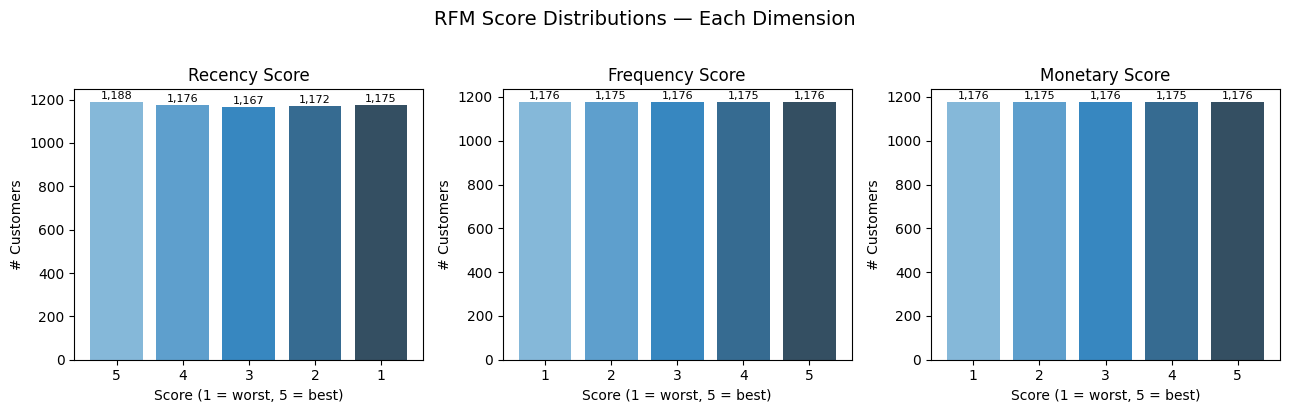

In [8]:
# ── Score distribution visual ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ['R Score', 'F Score', 'M Score'],
                           ['Recency Score', 'Frequency Score', 'Monetary Score']):
    counts = df_rfm[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette('Blues_d', 5))
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Score (1 = worst, 5 = best)')
    ax.set_ylabel('# Customers')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('RFM Score Distributions — Each Dimension', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 🏷️ 4. Customer Segmentation (11 Segments)

RFM score strings are mapped to 11 business-meaningful segments.  
Unmapped scores fall into **Other** — inspect these to refine the mapping over time.


In [9]:
# ── Segment lookup map ───────────────────────────────────────────────────
Champion           = [555,554,544,545,454,455,445]
Loyal_Customer     = [543,444,435,355,354,345,344,335]
Potential_Loyalist = [553,551,552,541,542,533,532,531,452,451,442,441,431,453,433,432,423,353,352,351,342,341,333,323]
New_Customer       = [512,511,422,421,412,411,311]
Promising          = [525,524,523,522,521,515,514,513,425,424,413,414,415,315,314,313]
Need_Attention     = [535,534,443,434,343,334,325,324]
About_to_Sleep     = [331,321,312,221,213,231,241,251]
At_Risk            = [255,254,245,244,253,252,243,242,235,234,225,224,153,152,145,143,142,135,134,133,125,124]
Cant_Lose_Them     = [155,154,144,214,215,115,114,113]
Hibernating        = [332,322,231,241,251,233,232,223,222,132,123,122,212,211]
Lost               = [111,112,121,131,141,151]

segment_map = {}
for code, label in [
    (Champion, 'Champion'), (Loyal_Customer, 'Loyal Customer'),
    (Potential_Loyalist, 'Potential Loyalist'), (New_Customer, 'New Customer'),
    (Promising, 'Promising'), (Need_Attention, 'Need Attention'),
    (About_to_Sleep, 'About to Sleep'), (At_Risk, 'At Risk'),
    (Cant_Lose_Them, "Can't Lose Them"), (Hibernating, 'Hibernating'), (Lost, 'Lost')
]:
    for c in code:
        segment_map[str(c)] = label

df_rfm['Customer Segment'] = df_rfm['RFM Score'].map(segment_map).fillna('Other')

# Convert score columns to int for later arithmetic
for col in ['R Score', 'F Score', 'M Score']:
    df_rfm[col] = df_rfm[col].astype(int)

df_rfm['Recency']  = df_rfm['Recency'].astype(int)
df_rfm['Monetary'] = df_rfm['Monetary'].round(0).astype(int)

print(f"Total customers  : {df_rfm.shape[0]:,}")
print(f"Segments found   : {df_rfm['Customer Segment'].nunique()}")
print()
print(df_rfm['Customer Segment'].value_counts().to_string())

Total customers  : 5,878
Segments found   : 11

Customer Segment
Champion              1150
Hibernating           1037
Lost                   664
Loyal Customer         656
Potential Loyalist     606
At Risk                520
New Customer           344
Need Attention         342
About to Sleep         285
Promising              170
Can't Lose Them        104


## 🗺️ 5. Segment Size & Revenue Contribution

Two treemaps side-by-side: one by **customer count**, one by **revenue**.  
The gap between these two maps reveals which segments punch above or below their weight.

> 💡 **Key business insight:** If Champions are 15% of customers but 60%+ of revenue, every defection has outsized financial impact.


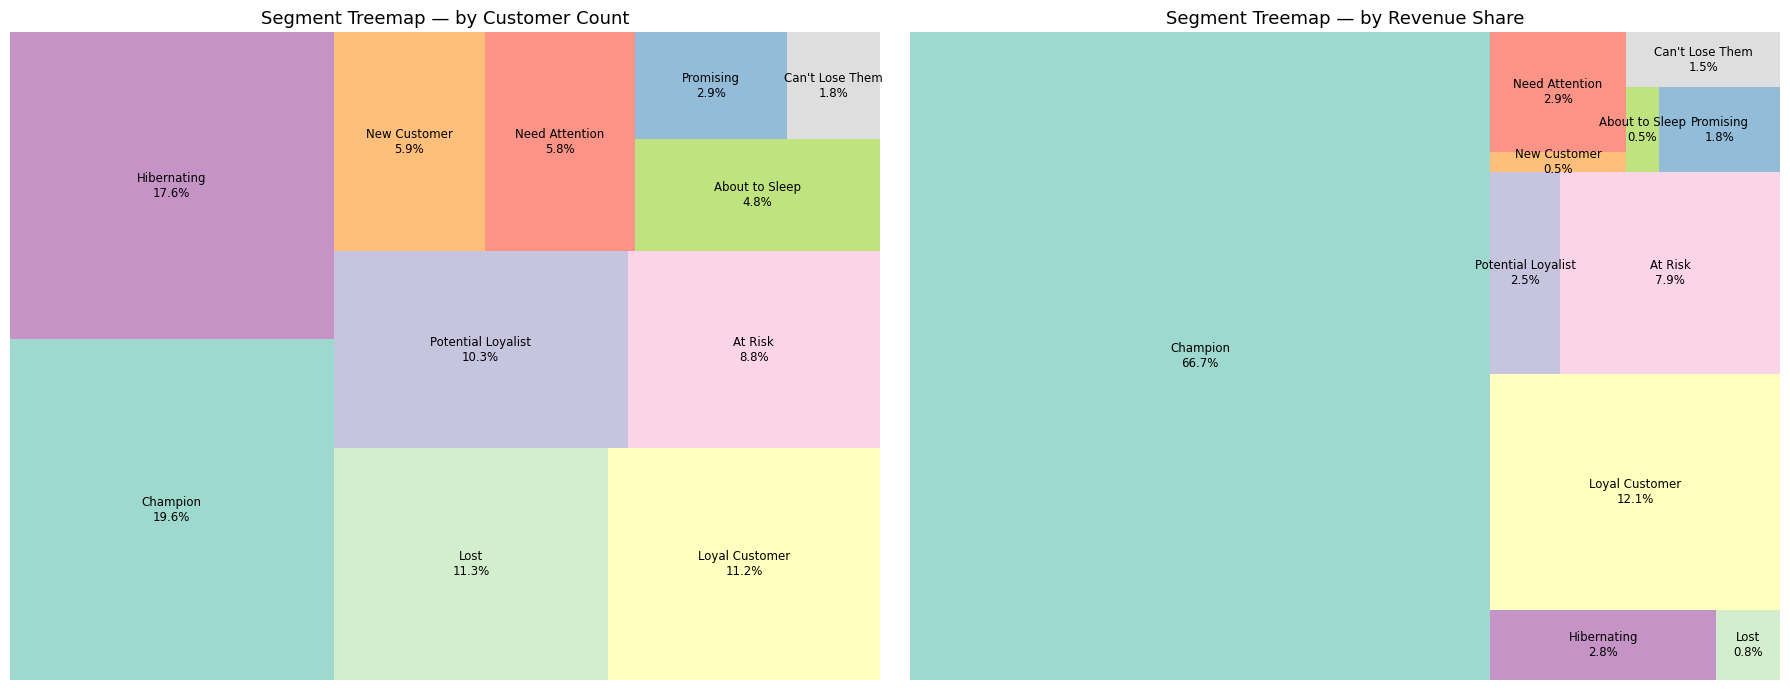

In [24]:
# ── Merge segment labels into transactions ───────────────────────────────
df_seg = df.merge(df_rfm[['Customer ID', 'Customer Segment']], on='Customer ID', how='left')

# ── Segment-level aggregation ─────────────────────────────────────────────
seg_counts = df_rfm['Customer Segment'].value_counts().reset_index()
seg_counts.columns = ['Customer Segment', 'Count']
seg_counts['Cust %'] = (seg_counts['Count'] / seg_counts['Count'].sum() * 100).round(1)

rev_seg = (
    df_seg.groupby('Customer Segment')['Total Price']
    .sum().reset_index(name='Revenue')
)
rev_seg['Rev %'] = (rev_seg['Revenue'] / rev_seg['Revenue'].sum() * 100).round(1)

seg_full = seg_counts.merge(rev_seg, on='Customer Segment')
seg_full['color'] = seg_full['Customer Segment'].map(color_map)

# ── Treemaps ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, size_col, pct_col, title in [
    (axes[0], 'Count',   'Cust %', 'Customer Count'),
    (axes[1], 'Revenue', 'Rev %',  'Revenue Share')
]:
    seg_full['label'] = seg_full.apply(
        lambda r: f"{r['Customer Segment']}\n{r[pct_col]:.1f}%", axis=1
    )
    plt.sca(ax)
    squarify.plot(
        sizes=seg_full[size_col],
        label=seg_full['label'],
        color=seg_full['color'],
        alpha=0.85,
        text_kwargs={'fontsize': 8.5},
        ax=ax
    )
    ax.set_title(f'Segment Treemap — by {title}', fontsize=13)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [25]:
# ── Insight print ─────────────────────────────────────────────────────────
print("=== Segment Summary: Customers vs Revenue ===")
print(seg_full[['Customer Segment','Count','Cust %','Revenue','Rev %']]
      .sort_values('Rev %', ascending=False)
      .to_string(index=False))

=== Segment Summary: Customers vs Revenue ===
  Customer Segment  Count  Cust %      Revenue  Rev %
          Champion   1150    19.6 11582332.235   66.7
    Loyal Customer    656    11.2  2109167.304   12.1
           At Risk    520     8.8  1367814.671    7.9
    Need Attention    342     5.8   502762.273    2.9
       Hibernating   1037    17.6   488451.140    2.8
Potential Loyalist    606    10.3   438215.072    2.5
         Promising    170     2.9   318559.200    1.8
   Can't Lose Them    104     1.8   259446.952    1.5
              Lost    664    11.3   137511.221    0.8
      New Customer    344     5.9    84429.670    0.5
    About to Sleep    285     4.8    86114.530    0.5


## 📅 6–8. Weekly Purchase Behavior by Segment Tier

Purchase counts are grouped by **week of month (1–4)** to reveal timing patterns.  
Use these patterns to schedule email/ad campaigns at peak activity windows.


In [38]:
# Ensure datetime
df_seg['InvoiceDate'] = pd.to_datetime(df_seg['InvoiceDate'], errors='coerce')

# Feature engineering
df_seg['WeekOfMonth'] = ((df_seg['InvoiceDate'].dt.day - 1) // 7 + 1).clip(upper=4)

WEEKS = [1, 2, 3, 4]

# safety color map
if 'color_map' not in globals():
    color_map = {}

In [40]:
# Visual Analytics Output
def plot_weekly_bar(segments_list, title, figsize=(12, 5)):

    weekly = (
        df_seg[df_seg['Customer Segment'].isin(segments_list)]
        .groupby(['Customer Segment', 'WeekOfMonth'])['Invoice']
        .nunique()
        .reset_index(name='Purchases')
    )

    n = len(segments_list)
    w = 0.7 / max(n, 1)
    off = np.linspace(-(n-1)/2 * w, (n-1)/2 * w, n)

    fig, ax = plt.subplots(figsize=figsize)

    for i, seg in enumerate(segments_list):

        data = (
            weekly[weekly['Customer Segment'] == seg]
            .set_index('WeekOfMonth')
            .reindex(WEEKS, fill_value=0)
        )

        bars = ax.bar(
            [wk + off[i] for wk in WEEKS],
            data['Purchases'].values,
            width=w,
            label=seg,
            color=color_map.get(seg, None)
        )

        for bar in bars:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    h + 0.5,
                    f'{int(h)}',
                    ha='center',
                    va='bottom',
                    fontsize=8
                )

    ax.set_xticks(WEEKS)
    ax.set_xticklabels([f'Week {w}' for w in WEEKS])
    ax.set_title(title)
    ax.set_xlabel('Week of Month')
    ax.set_ylabel('Unique Purchases')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [58]:
# Table Analytics Output
def show_weekly_table(segments_list, title):

    weekly = (
        df_seg[df_seg['Customer Segment'].isin(segments_list)]
        .groupby(['Customer Segment', 'WeekOfMonth'])['Invoice']
        .nunique()
        .reset_index(name='Purchases')
    )

    pivot = (
        weekly.pivot(index='WeekOfMonth',
                     columns='Customer Segment',
                     values='Purchases')
        .fillna(0)
        .astype(int)
    )

    display(pivot)
    peak = pivot.sum(axis=1).idxmax()
    print(f"📌 Peak week: Week {peak} — optimize campaigns here.")
    
    return None

### 6a. High-Value Segments — Champion · Loyal Customer · Potential Loyalist

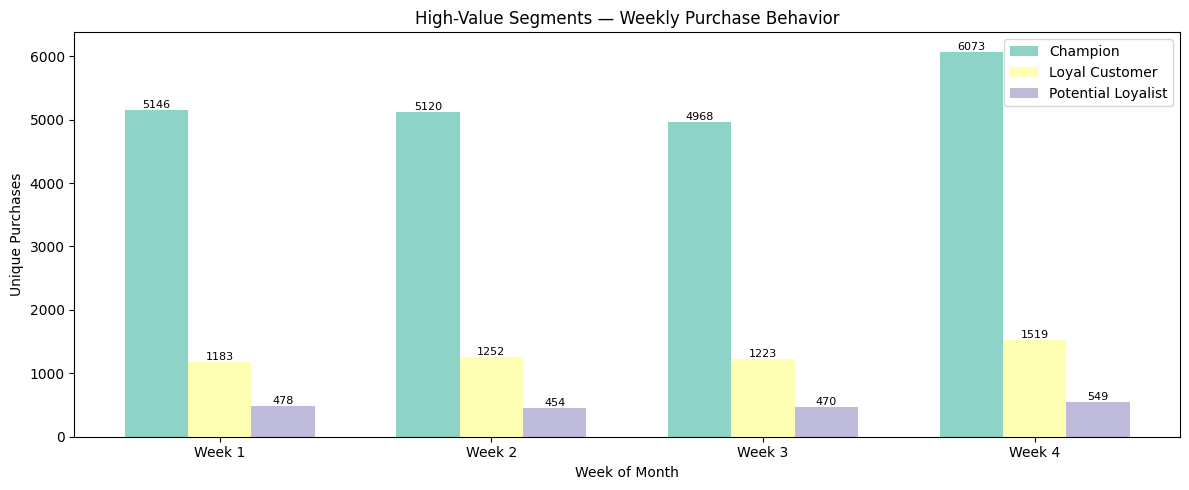

In [59]:
plot_weekly_bar(
    ['Champion', 'Loyal Customer', 'Potential Loyalist'],
    'High-Value Segments — Weekly Purchase Behavior'
)

In [60]:
show_weekly_table(
    ['Champion', 'Loyal Customer', 'Potential Loyalist'],
    'High-Value Segments — Weekly Purchase Behavior'
)

Customer Segment,Champion,Loyal Customer,Potential Loyalist
WeekOfMonth,,,
1,5146,1183,478
2,5120,1252,454
3,4968,1223,470
4,6073,1519,549


📌 Peak week: Week 4 — optimize campaigns here.


**Insight:** High-value customers buy consistently. Look for any week 3–4 uplift — this is the natural re-order window.  
**Action:** VIP early-access emails in the week *before* their peak buy week.


### 6b. Mid-Value Segments — Need Attention · Promising · New Customer · About to Sleep

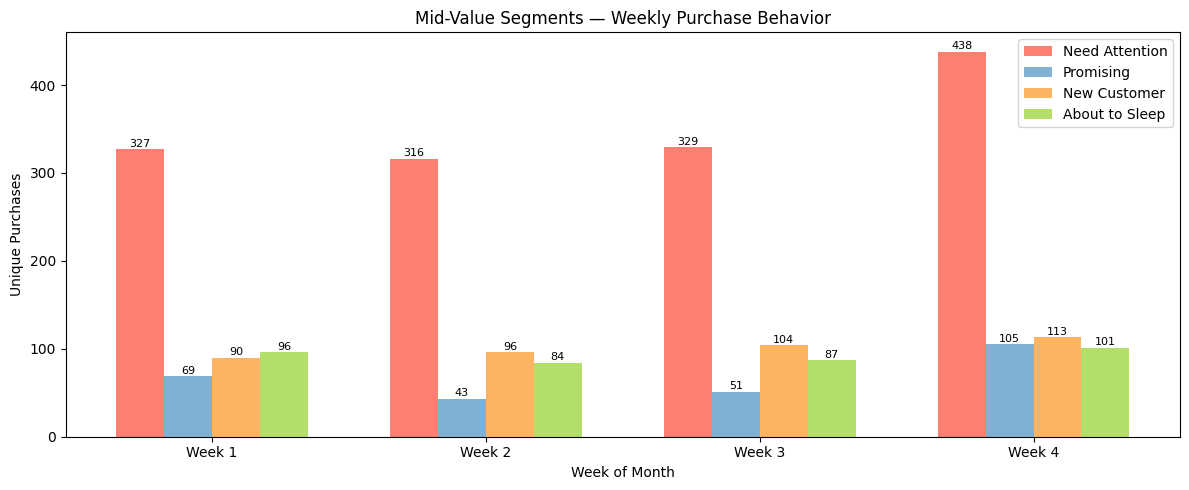

In [61]:
plot_weekly_bar(
    ['Need Attention', 'Promising', 'New Customer', 'About to Sleep'],
    'Mid-Value Segments — Weekly Purchase Behavior'
)

In [62]:
show_weekly_table(
    ['Need Attention', 'Promising', 'New Customer', 'About to Sleep'],
    'Mid-Value Segments — Weekly Purchase Behavior'
)

Customer Segment,About to Sleep,Need Attention,New Customer,Promising
WeekOfMonth,,,,
1,96,327,90,69
2,84,316,96,43
3,87,329,104,51
4,101,438,113,105


📌 Peak week: Week 4 — optimize campaigns here.


**Insight:** Mid-value customers show inconsistent weekly patterns — the biggest upsell opportunity.  
**Action:** Bundle deals and product recommendations timed to their most active week.


### 6c. Low-Value / At-Risk Segments — At Risk · Hibernating · Can't Lose Them · Lost

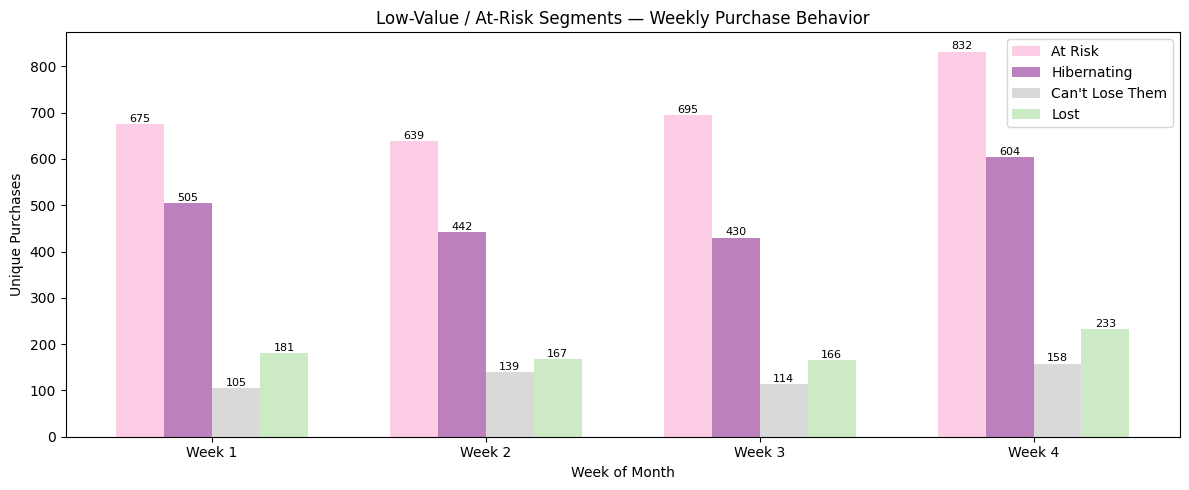

In [63]:
plot_weekly_bar(
    ['At Risk', 'Hibernating', "Can't Lose Them", 'Lost'],
    "Low-Value / At-Risk Segments — Weekly Purchase Behavior"
)

In [64]:
show_weekly_table(
    ['At Risk', 'Hibernating', "Can't Lose Them", 'Lost'],
    "Low-Value / At-Risk Segments — Weekly Purchase Behavior"
)

Customer Segment,At Risk,Can't Lose Them,Hibernating,Lost
WeekOfMonth,,,,
1,675,105,505,181
2,639,139,442,167
3,695,114,430,166
4,832,158,604,233


📌 Peak week: Week 4 — optimize campaigns here.


**Insight:** Low-value segments have sparse, declining purchase frequency.  
**Action:** Low-cost automated reactivation — discount emails, retargeting ads. Avoid high-spend outreach on `Lost`.


## 📊 9. Full Segment Snapshot Table

Executive-ready summary: one row per segment, covering size, spend, recency, and revenue share.


In [15]:
# ── Build snapshot ───────────────────────────────────────────────────────
snap = df_rfm.groupby('Customer Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean')
).reset_index()

snap['Avg_Recency']   = snap['Avg_Recency'].round(0).astype(int)
snap['Avg_Frequency'] = snap['Avg_Frequency'].round(1)
snap['Avg_Monetary']  = snap['Avg_Monetary'].round(0).astype(int)

snap = snap.merge(rev_seg[['Customer Segment','Rev %']], on='Customer Segment')
snap.columns = ['Segment', 'Customers', 'Avg Recency (days)', 'Avg Frequency', 'Avg Spend (£)', 'Revenue %']

# Add tier
tier_map = {
    'Champion': 'High', 'Loyal Customer': 'High', 'Potential Loyalist': 'High',
    'Need Attention': 'Mid', 'Promising': 'Mid', 'New Customer': 'Mid', 'About to Sleep': 'Mid',
    'At Risk': 'Low', 'Hibernating': 'Low', "Can't Lose Them": 'Low', 'Lost': 'Low', 'Other': 'Other'
}
snap['Tier'] = snap['Segment'].map(tier_map)

snap.sort_values(['Tier', 'Customers'], ascending=[True, False]).reset_index(drop=True)

,Segment,Customers,Avg Recency (days),Avg Frequency,Avg Spend (£),Revenue %,Tier
0,Champion,1150,18,18.5,10072,66.7,High
1,Loyal Customer,656,76,7.9,3215,12.1,High
2,Potential Loyalist,606,54,3.2,723,2.5,High
3,Hibernating,1037,340,1.9,471,2.8,Low
4,Lost,664,568,1.1,207,0.8,Low
5,At Risk,520,364,5.5,2630,7.9,Low
6,Can't Lose Them,104,486,5.0,2495,1.5,Low
7,New Customer,344,54,1.2,245,0.5,Mid
8,Need Attention,342,69,4.1,1470,2.9,Mid
9,About to Sleep,285,222,1.3,302,0.5,Mid


## 🔵 10. Behavior Comparison — Scatter Plot

- **X-axis:** Avg Days Since Last Purchase (higher = more dormant)
- **Y-axis:** Avg Spend per Customer (higher = more valuable)
- **Bubble size:** Number of customers in the segment

**Expected pattern:** Champions cluster top-left (recent + high spend); Lost/Hibernating cluster bottom-right.


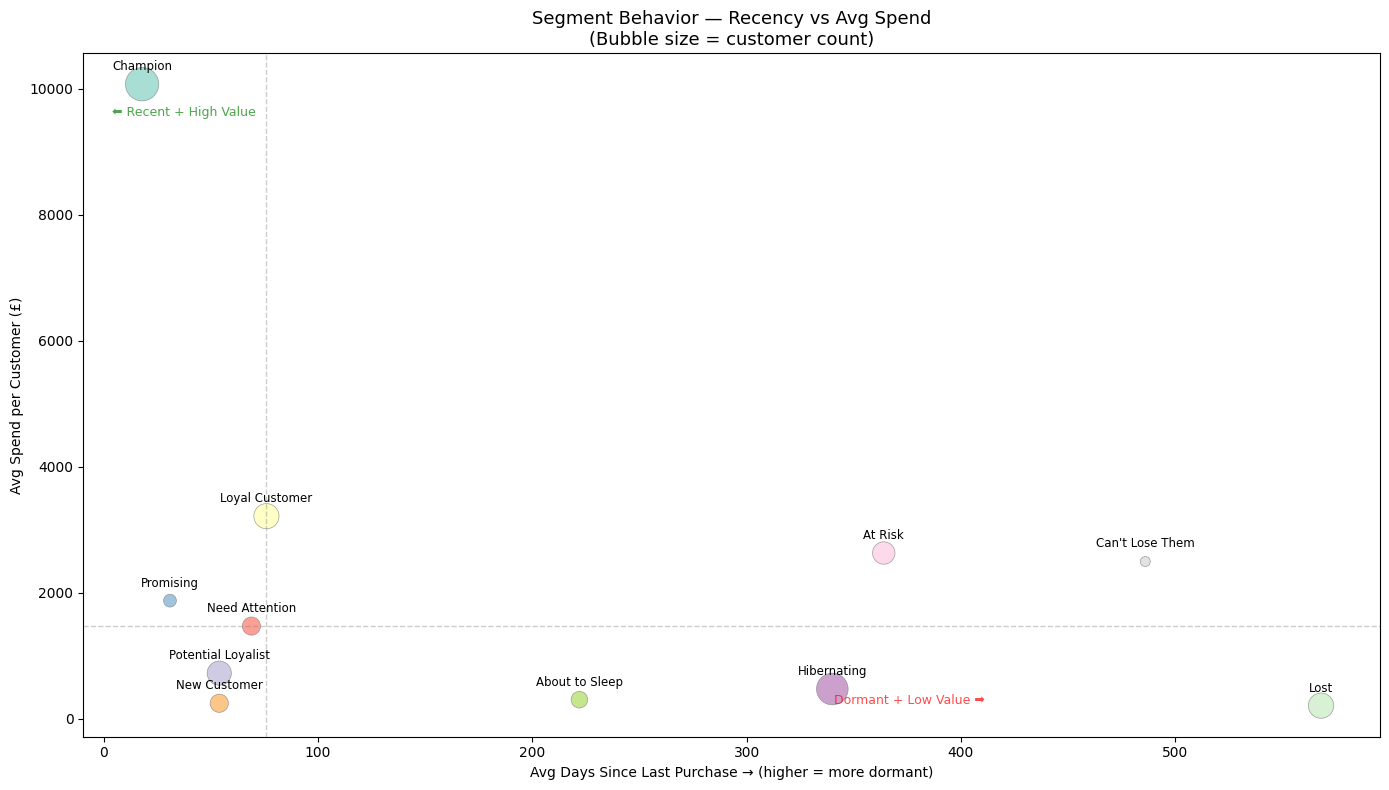


=== Most Active (low recency, high spend) ===
     Segment  Avg Recency (days)  Avg Spend (£)
    Champion                  18          10072
   Promising                  31           1874
New Customer                  54            245

=== Most Dormant (high recency, low spend) ===
        Segment  Avg Recency (days)  Avg Spend (£)
           Lost                 568            207
Can't Lose Them                 486           2495
        At Risk                 364           2630


In [16]:
snap_plot = snap.copy()
snap_plot['color'] = snap_plot['Segment'].map(color_map)

fig, ax = plt.subplots(figsize=(14, 8))
sc = ax.scatter(
    snap_plot['Avg Recency (days)'],
    snap_plot['Avg Spend (£)'],
    s=snap_plot['Customers'] * 0.5,          # scale bubble size
    c=snap_plot['color'],
    alpha=0.75, edgecolors='gray', linewidths=0.5
)

for _, row in snap_plot.iterrows():
    ax.annotate(
        row['Segment'],
        (row['Avg Recency (days)'], row['Avg Spend (£)']),
        fontsize=8.5, ha='center', va='bottom',
        xytext=(0, 8), textcoords='offset points'
    )

# Quadrant reference lines
mid_r = snap_plot['Avg Recency (days)'].median()
mid_m = snap_plot['Avg Spend (£)'].median()
ax.axvline(mid_r, color='gray', linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(mid_m, color='gray', linestyle='--', alpha=0.4, linewidth=1)

ax.text(mid_r * 0.05, snap_plot['Avg Spend (£)'].max() * 0.95,
        '⬅ Recent + High Value', fontsize=9, color='green', alpha=0.7)
ax.text(snap_plot['Avg Recency (days)'].max() * 0.6, snap_plot['Avg Spend (£)'].min() * 1.1,
        'Dormant + Low Value ➡', fontsize=9, color='red', alpha=0.7)

ax.set_title('Segment Behavior — Recency vs Avg Spend\n(Bubble size = customer count)', fontsize=13)
ax.set_xlabel('Avg Days Since Last Purchase → (higher = more dormant)')
ax.set_ylabel('Avg Spend per Customer (£)')
plt.tight_layout()
plt.show()

print("\n=== Most Active (low recency, high spend) ===")
print(snap_plot.nsmallest(3, 'Avg Recency (days)')[['Segment','Avg Recency (days)','Avg Spend (£)']].to_string(index=False))
print("\n=== Most Dormant (high recency, low spend) ===")
print(snap_plot.nlargest(3, 'Avg Recency (days)')[['Segment','Avg Recency (days)','Avg Spend (£)']].to_string(index=False))

## 💎 11. CV-RFM Analysis — Customer Value Within Segments

Not all customers in a segment are equal. A **weighted CV Score** (Monetary weighted 40%) identifies  
High / Mid / Low value customers *within* each segment.

> 💡 **Why this matters:** A "Loyal Customer" with a CV score of `Low Value` should be treated differently  
from a "Loyal Customer" with `High Value` — the upsell opportunity is very different.


In [17]:
# ── Weighted CV Score ────────────────────────────────────────────────────
df_rfm['CV Score'] = (
    df_rfm['R Score'] * 0.3 +
    df_rfm['F Score'] * 0.3 +
    df_rfm['M Score'] * 0.4
)

df_rfm['CV Tier'] = pd.cut(
    df_rfm['CV Score'],
    bins=[0, 2, 3.5, 5],
    labels=['Low Value', 'Mid Value', 'High Value']
)

# ── Pivot ─────────────────────────────────────────────────────────────────
cv_pivot = (
    df_rfm.groupby(['Customer Segment', 'CV Tier'])
    .size().unstack(fill_value=0)
)
cv_pivot = cv_pivot.reindex(columns=['Low Value', 'Mid Value', 'High Value'], fill_value=0)
cv_pivot['Total'] = cv_pivot.sum(axis=1)
cv_pivot = cv_pivot.sort_values('Total', ascending=False)

print("=== CV Tier Distribution per Segment ===")
print(cv_pivot.to_string())

=== CV Tier Distribution per Segment ===
CV Tier             Low Value  Mid Value  High Value  Total
Customer Segment                                           
Champion                    0          0        1150   1150
Hibernating               578        459           0   1037
Lost                      664          0           0    664
Loyal Customer              0          0         656    656
Potential Loyalist          0        507          99    606
At Risk                     0        441          79    520
New Customer              163        181           0    344
Need Attention              0        161         181    342
About to Sleep            240         45           0    285
Promising                   0        156          14    170
Can't Lose Them            33         60          11    104


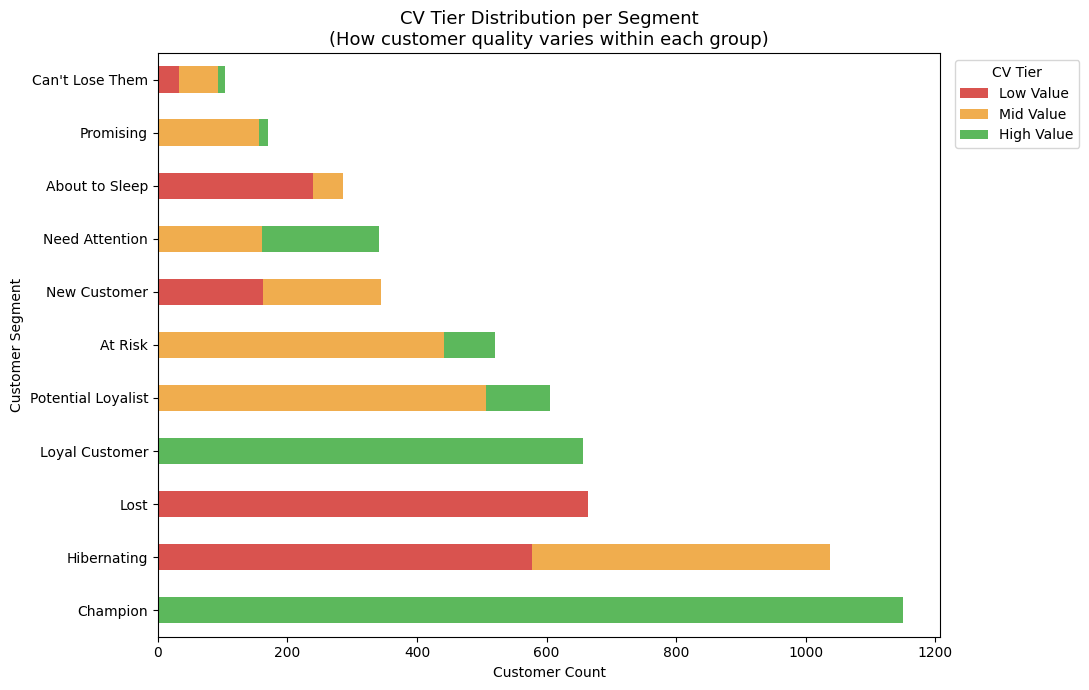

In [65]:
# ── Stacked bar ──────────────────────────────────────────────────────────
cv_plot = cv_pivot.drop(columns='Total').copy()

ax = cv_plot.plot(
    kind='barh', stacked=True, figsize=(11, 7),
    color=['#d9534f', '#f0ad4e', '#5cb85c']
)
plt.title('CV Tier Distribution per Segment\n(How customer quality varies within each group)', fontsize=13)
plt.xlabel('Customer Count')
plt.ylabel('Customer Segment')
plt.legend(title='CV Tier', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [67]:
# ── Key finding ───────────────────────────────────────────────────────────
print("\n=== High-Value customers outside top segments ===")
print("These are upgrade candidates — push them toward Champion/Loyal behaviour.\n")
high_val_mid = df_rfm[
    (df_rfm['CV Tier'] == 'High Value') &
    (~df_rfm['Customer Segment'].isin(['Champion', 'Loyal Customer']))
].groupby('Customer Segment')['Customer ID'].count().sort_values(ascending=False)
print(high_val_mid.to_string())


=== High-Value customers outside top segments ===
These are upgrade candidates — push them toward Champion/Loyal behaviour.

Customer Segment
Need Attention        181
Potential Loyalist     99
At Risk                79
Promising              14
Can't Lose Them        11


## 📈 12. Tier Opportunity Analysis — Revenue vs Customer Share

Comparing **customer %** vs **revenue %** per tier reveals investment priority:  
- High gap (small customers, big revenue) → **protect & retain**  
- Mid tier → **develop & upsell**  
- Low tier → **low-cost reactivation only**


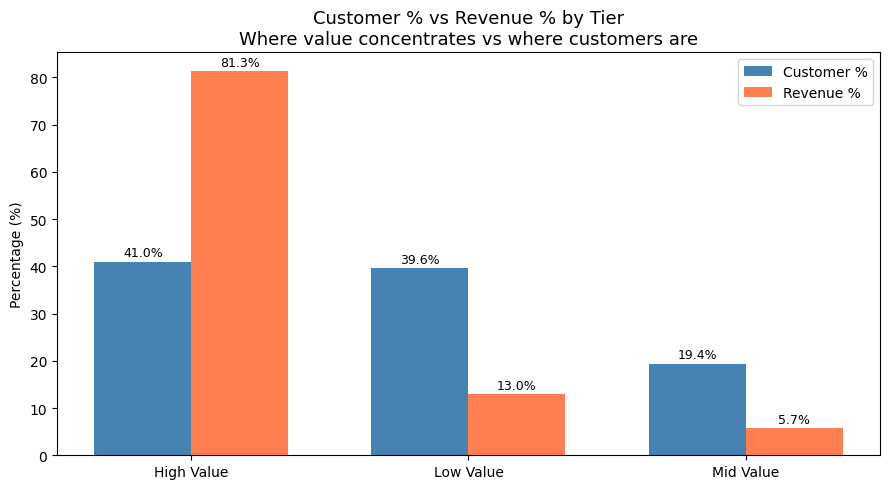

In [68]:
# ── Tier labels on transactions + RFM ────────────────────────────────────
full_tier_map = {
    'Champion': 'High Value', 'Loyal Customer': 'High Value', 'Potential Loyalist': 'High Value',
    'Need Attention': 'Mid Value', 'Promising': 'Mid Value',
    'New Customer': 'Mid Value', 'About to Sleep': 'Mid Value',
    'At Risk': 'Low Value', 'Hibernating': 'Low Value',
    "Can't Lose Them": 'Low Value', 'Lost': 'Low Value', 'Other': 'Other'
}

df_seg['Tier']  = df_seg['Customer Segment'].map(full_tier_map)
df_rfm['Tier']  = df_rfm['Customer Segment'].map(full_tier_map)

tier_rev  = df_seg.groupby('Tier')['Total Price'].sum().reset_index(name='Revenue')
tier_rev['Rev %'] = (tier_rev['Revenue'] / tier_rev['Revenue'].sum() * 100).round(1)

tier_cust = df_rfm.groupby('Tier')['Customer ID'].count().reset_index(name='Customers')
tier_cust['Cust %'] = (tier_cust['Customers'] / tier_cust['Customers'].sum() * 100).round(1)

opp = tier_cust.merge(tier_rev[['Tier','Rev %']], on='Tier')
opp = opp[opp['Tier'] != 'Other'].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(opp))
w = 0.35

b1 = ax.bar(x - w/2, opp['Cust %'], w, label='Customer %', color='steelblue')
b2 = ax.bar(x + w/2, opp['Rev %'],  w, label='Revenue %',  color='coral')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(opp['Tier'])
ax.set_title('Customer % vs Revenue % by Tier\nWhere value concentrates vs where customers are', fontsize=13)
ax.set_ylabel('Percentage (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
# Summary
print("=== Tier Summary ===")
print(opp.to_string(index=False))

=== Tier Summary ===
      Tier  Customers  Cust %  Rev %
High Value       2412    41.0   81.3
 Low Value       2325    39.6   13.0
 Mid Value       1141    19.4    5.7


## 💡 13. Key Insights — Stakeholder-Ready Findings

This section synthesises the analysis into concise business conclusions.  
*(Update the percentages below after running the notebook on your data.)*

---

### 🔴 Revenue Concentration
> **Top 3 segments (Champion, Loyal, Potential Loyalist) generate the majority of revenue from a minority of customers.**  
> Every defection in this group has outsized P&L impact. Retention is cheaper than acquisition.

### 🟡 Mid-Segment Growth Opportunity
> **Need Attention, Promising, and New Customer segments are the biggest untapped growth lever.**  
> They purchase consistently but haven't hit their frequency/monetary ceiling. A targeted upsell campaign here can move them into the Loyal tier.

### 🔵 Campaign Timing
> **Purchases cluster in weeks 3–4 of the month** for high-value segments.  
> Sending campaigns 3–5 days *before* peak week maximises open rate and conversion.

### ⚪ Low-Value Reactivation
> **At-Risk and Hibernating customers need low-cost outreach only.**  
> High-spend campaigns on these segments destroy ROI. Use automated email sequences with small discount incentives.

### 🟢 CV-RFM Hidden Gems
> **Some Mid-segment customers have High CV scores — they are upgrade candidates.**  
> A personalised push (product bundle, loyalty programme invite) can tip them into Champion behaviour.


In [20]:
# ── Auto-generate insight numbers from data ───────────────────────────────
high_segs  = ['Champion', 'Loyal Customer', 'Potential Loyalist']
high_rev_pct  = rev_seg[rev_seg['Customer Segment'].isin(high_segs)]['Rev %'].sum()
high_cust_pct = seg_counts[seg_counts['Customer Segment'].isin(high_segs)]['Cust %'].sum()

low_segs   = ['At Risk', 'Hibernating', 'Lost', "Can't Lose Them"]
low_cust   = seg_counts[seg_counts['Customer Segment'].isin(low_segs)]['Count'].sum()

print("=" * 55)
print("  AUTOMATED INSIGHT SUMMARY")
print("=" * 55)
print(f"  High-value segments (top 3)")
print(f"    Customers : {high_cust_pct:.1f}% of base")
print(f"    Revenue   : {high_rev_pct:.1f}% of total revenue")
print()
print(f"  At-risk / low-value pool")
print(f"    Customers : {low_cust:,} customers need reactivation")
print()

# Peak week
weekly_all = (
    df_seg.groupby('WeekOfMonth')['Invoice'].nunique()
)
peak_wk = weekly_all.idxmax()
print(f"  Campaign timing")
print(f"    Peak week : Week {peak_wk} ({weekly_all[peak_wk]:,} purchases)")
print("=" * 55)

  AUTOMATED INSIGHT SUMMARY
  High-value segments (top 3)
    Customers : 41.1% of base
    Revenue   : 81.3% of total revenue

  At-risk / low-value pool
    Customers : 2,325 customers need reactivation

  Campaign timing
    Peak week : Week 4 (10,725 purchases)


## 🎯 14. Marketing Strategy — Segment → Action Map

Each segment receives a differentiated strategy based on its RFM profile and tier.


In [21]:
# ── Strategy table ───────────────────────────────────────────────────────
strategy_map = {
    'Champion':           ('Protect',         'VIP offers, early access, exclusive drops',         'High'),
    'Loyal Customer':     ('Retain',           'Loyalty rewards, personalised follow-ups',          'High'),
    'Potential Loyalist': ('Nurture',          'Bundle deals, upsell to Loyal tier',                'High'),
    'Promising':          ('Develop',          'Cross-sell, product discovery campaigns',           'Mid'),
    'New Customer':       ('Onboard',          'Welcome series, first-purchase incentives',         'Mid'),
    'Need Attention':     ('Re-engage',        'Win-back emails, limited-time discounts',           'Mid'),
    'About to Sleep':     ('Prevent Churn',    'Reminder emails, targeted promotions',              'Mid'),
    'At Risk':            ('Recover',          'Discount campaigns, personalised outreach',         'Low'),
    "Can't Lose Them":    ('Urgent Recovery',  'High-value retention offers, direct contact',      'Low'),
    'Hibernating':        ('Reactivation',     'Automated reactivation discounts',                  'Low'),
    'Lost':               ('Low Priority',     'Low-cost automated reminders only',                 'Low'),
}

reco = pd.DataFrame([
    {'Segment': seg, 'Strategy': v[0], 'Recommended Action': v[1], 'Tier': v[2]}
    for seg, v in strategy_map.items()
])

reco = reco.merge(snap[['Segment','Customers','Revenue %']], on='Segment', how='left')
reco = reco.sort_values(['Tier', 'Revenue %'], ascending=[True, False]).reset_index(drop=True)

reco

,Segment,Strategy,Recommended Action,Tier,Customers,Revenue %
0,Champion,Protect,"VIP offers, early access, exclusive drops",High,1150,66.7
1,Loyal Customer,Retain,"Loyalty rewards, personalised follow-ups",High,656,12.1
2,Potential Loyalist,Nurture,"Bundle deals, upsell to Loyal tier",High,606,2.5
3,At Risk,Recover,"Discount campaigns, personalised outreach",Low,520,7.9
4,Hibernating,Reactivation,Automated reactivation discounts,Low,1037,2.8
5,Can't Lose Them,Urgent Recovery,"High-value retention offers, direct contact",Low,104,1.5
6,Lost,Low Priority,Low-cost automated reminders only,Low,664,0.8
7,Need Attention,Re-engage,"Win-back emails, limited-time discounts",Mid,342,2.9
8,Promising,Develop,"Cross-sell, product discovery campaigns",Mid,170,1.8
9,New Customer,Onboard,"Welcome series, first-purchase incentives",Mid,344,0.5


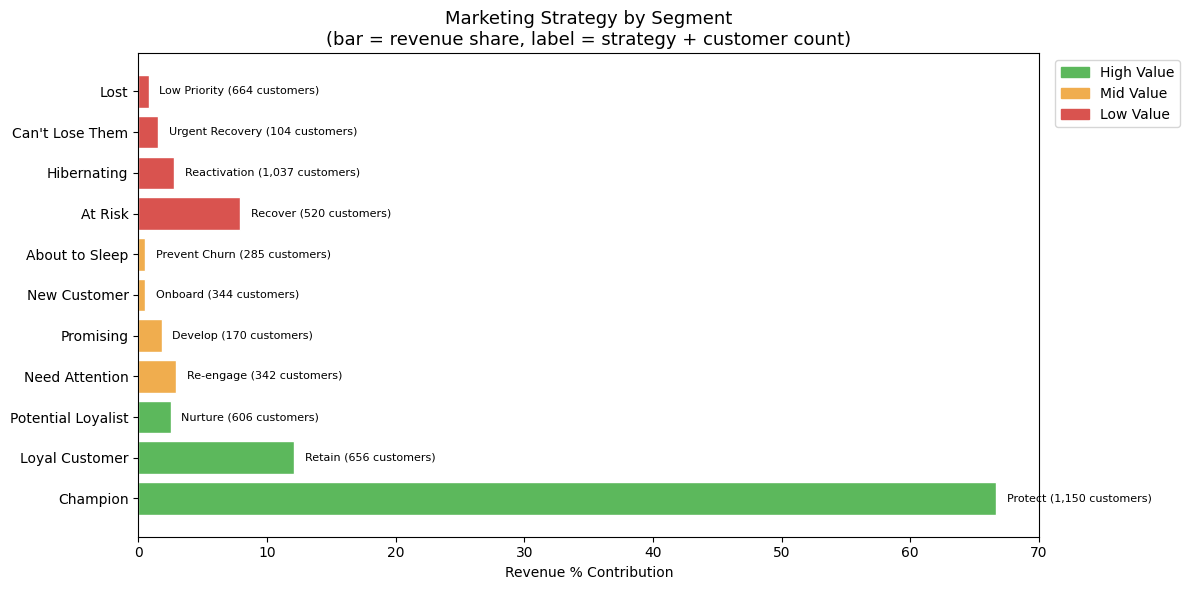

In [22]:
# ── Visual: strategy action heatmap by tier ──────────────────────────────
tier_order = ['High', 'Mid', 'Low']
reco_plot  = reco[reco['Tier'].isin(tier_order)].copy()
reco_plot['Tier_order'] = reco_plot['Tier'].map({'High': 0, 'Mid': 1, 'Low': 2})
reco_plot = reco_plot.sort_values('Tier_order')

fig, ax = plt.subplots(figsize=(12, 6))
colors = reco_plot['Tier'].map({'High': '#5cb85c', 'Mid': '#f0ad4e', 'Low': '#d9534f'})

bars = ax.barh(reco_plot['Segment'], reco_plot['Revenue %'], color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, reco_plot.iterrows()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"  {row['Strategy']} ({row['Customers']:,} customers)",
            va='center', fontsize=8)

ax.set_xlabel('Revenue % Contribution')
ax.set_title('Marketing Strategy by Segment\n(bar = revenue share, label = strategy + customer count)', fontsize=13)

patches = [mpatches.Patch(color=c, label=t) for t, c in
           [('High Value','#5cb85c'), ('Mid Value','#f0ad4e'), ('Low Value','#d9534f')]]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 🗓️ 15. Implementation Roadmap

A 3-month phased rollout aligned to segment tiers.

| Month | Phase | Focus | KPIs to Track |
|-------|-------|-------|---------------|
| **Month 1** | Launch | Protect High-Value (Champions, Loyal) + Onboard New Customers | Repeat purchase rate, Email open rate |
| **Month 2** | Develop | Mid-Value upsell campaigns (Need Attention, Promising) | Revenue per segment, Conversion rate |
| **Month 3** | Recover | Reactivation of At-Risk + Hibernating; Low-cost Lost touchpoints | Reactivation rate, Campaign ROI |

---

### 📏 KPIs to Monitor Monthly
- **Repeat purchase rate** per segment (target: +5% for High-Value)
- **Revenue per segment** (watch for Mid → High migration)
- **Campaign ROI** by tier (Low-value campaigns must break even within 60 days)
- **Segment migration rate** (customers moving from Mid to High tier = success signal)

---

### ⚠️ Risks to Watch
- Champions declining in recency → early churn signal → trigger VIP intervention immediately
- New Customers with only 1 purchase → at risk of never returning → 7-day follow-up email critical
- "Can't Lose Them" → high historical spend but dormant → worthy of personal outreach (high ROI)


## 💾 16. Export

In [23]:
# ── Export all outputs ───────────────────────────────────────────────────
df_rfm.to_csv('rfm_ebay_final.csv', index=False)
snap.to_csv('rfm_segment_snapshot.csv', index=False)
reco.to_csv('rfm_recommendations.csv', index=False)
cv_pivot.to_csv('rfm_cv_analysis.csv')
opp.to_csv('rfm_tier_opportunity.csv', index=False)

print('✅ Exported:')
for fname in ['rfm_ebay_final.csv', 'rfm_segment_snapshot.csv',
              'rfm_recommendations.csv', 'rfm_cv_analysis.csv', 'rfm_tier_opportunity.csv']:
    print(f'   {fname}')

✅ Exported:
   rfm_ebay_final.csv
   rfm_segment_snapshot.csv
   rfm_recommendations.csv
   rfm_cv_analysis.csv
   rfm_tier_opportunity.csv
